<a href="https://colab.research.google.com/github/usha-sj/portfolio-optimizer/blob/dev/portfolio_optimizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 13.7 MB/s eta 0:00:00


[*********************100%***********************]  4 of 4 completed


Tickers: ['AAPL', 'MSFT', 'GOOGL', 'AMZN']
Expected Annual Return: 43.11%
Expected Annual Vol   : 20.59%
Sharpe (rf=0%): 2.09

Optimal Weights
    AAPL: 55.26%
    MSFT: 34.54%
   GOOGL: 10.20%
    AMZN: 0.00%


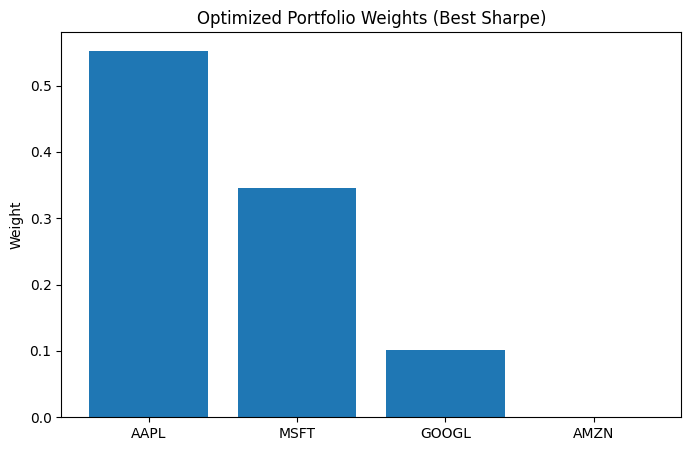

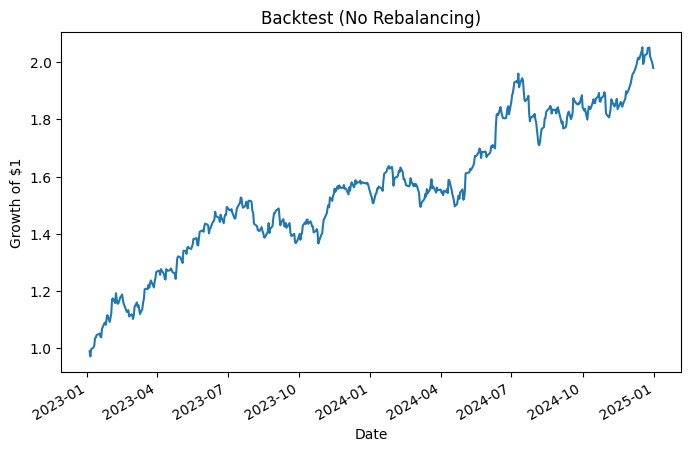

Saved: /content/optimized_weights.csv, /content/portfolio_summary.csv


In [16]:
# =========================
# Robust Portfolio Optimizer (Final - with Solver Fix)
# =========================
!pip -q install yfinance cvxpy pandas numpy matplotlib ecos scs

import warnings, numpy as np, pandas as pd, yfinance as yf, cvxpy as cp, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (8,5)

# ---------- Inputs (edit these) ----------
TICKERS = ["AAPL", "MSFT", "GOOGL", "AMZN"]
START   = "2023-01-01"
END     = "2025-01-01"

RISK_FREE    = 0.00     # use 0 first to avoid infeasibility
LONG_ONLY    = True
WEIGHT_CAP   = 0.7      # set 1.0 to remove cap
TRADING_DAYS = 252
RIDGE_EPS    = 1e-6     # small stabilizer for covariance

# ---------- Download prices ----------
raw = yf.download(TICKERS, start=START, end=END, group_by='column', auto_adjust=False)

def extract_adj_close(df):
    cols = df.columns
    if isinstance(cols, pd.MultiIndex):
        lvl0 = cols.get_level_values(0)
        if 'Adj Close' in lvl0:
            px = df['Adj Close']
        elif 'Close' in lvl0:
            px = df['Close']
        else:
            raise KeyError("No price columns found")
    else:
        if 'Adj Close' in cols:
            px = df[['Adj Close']].rename(columns={'Adj Close': TICKERS[0]})
        elif 'Close' in cols:
            px = df[['Close']].rename(columns={'Close': TICKERS[0]})
        else:
            raise KeyError("No price columns found")
    return px.dropna(how='all')

prices = extract_adj_close(raw)
returns = prices.pct_change().dropna()
mean_annual = returns.mean() * TRADING_DAYS
cov_annual  = returns.cov() * TRADING_DAYS

# ---------- Build optimization problem ----------
Sigma = cov_annual.values + RIDGE_EPS * np.eye(len(TICKERS))
mu    = mean_annual.values
n     = len(TICKERS)
w     = cp.Variable(n)

constraints = [cp.sum(w) == 1]
if LONG_ONLY:
    constraints += [w >= 0, w <= WEIGHT_CAP]

risk_expr = cp.quad_form(w, Sigma)

# compute feasible bounds for target return
prob_max = cp.Problem(cp.Maximize(mu @ w), constraints)
prob_max.solve(solver=cp.SCS, verbose=False)
if w.value is None:
    raise RuntimeError("Could not solve max-return problem.")
ret_max = float(mu @ w.value)
ret_min = float(min(mu))

targets = np.linspace(ret_min, ret_max, 30)
solutions = []

for target in targets:
    w_tmp = cp.Variable(n)
    cons_tmp = [cp.sum(w_tmp) == 1]
    if LONG_ONLY:
        cons_tmp += [w_tmp >= 0, w_tmp <= WEIGHT_CAP]
    cons_tmp += [mu @ w_tmp >= target]
    prob = cp.Problem(cp.Minimize(cp.quad_form(w_tmp, Sigma)), cons_tmp)
    prob.solve(solver=cp.SCS, verbose=False)
    if w_tmp.value is None:
        continue
    w_opt = np.clip(w_tmp.value, 0, None) if LONG_ONLY else w_tmp.value
    w_opt /= w_opt.sum()
    ret = float(mu @ w_opt)
    vol = float(np.sqrt(w_opt.T @ Sigma @ w_opt))
    sharpe = (ret - RISK_FREE) / (vol + 1e-12)
    solutions.append((ret, vol, sharpe, w_opt))

if not solutions:
    raise RuntimeError("No feasible portfolios found. Try lowering constraints or extending dates.")

best = max(solutions, key=lambda x: x[2])
ret_star, vol_star, sharpe_star, w_star = best

# ---------- Results ----------
print("Tickers:", TICKERS)
print(f"Expected Annual Return: {ret_star:.2%}")
print(f"Expected Annual Vol   : {vol_star:.2%}")
print(f"Sharpe (rf={RISK_FREE:.0%}): {sharpe_star:.2f}\n")
print("Optimal Weights")
for t, wt in zip(TICKERS, w_star):
    print(f"  {t:>6}: {wt:.2%}")

# ---------- Plots ----------
plt.bar(TICKERS, w_star)
plt.title("Optimized Portfolio Weights (Best Sharpe)")
plt.ylabel("Weight")
plt.show()

eq_curve = (1 + returns[TICKERS].dot(w_star)).cumprod()
eq_curve.plot(title="Backtest (No Rebalancing)")
plt.ylabel("Growth of $1")
plt.show()

# ---------- Save results ----------
weights_df = pd.DataFrame({"ticker": TICKERS, "weight": w_star})
summary_df = pd.DataFrame({
    "expected_return_annual":[ret_star],
    "expected_vol_annual":[vol_star],
    "sharpe":[sharpe_star]
})
weights_df.to_csv("/content/optimized_weights.csv", index=False)
summary_df.to_csv("/content/portfolio_summary.csv", index=False)
print("Saved: /content/optimized_weights.csv, /content/portfolio_summary.csv")